# Case - Marketing

- In a fast-paced industry, relying solely on intuition is no longer enough to determine production volumes and inventory management. By leveraging historical marketing performance data—from ad clicks to social media views to direct consumer interactions—we can understand potential buyers' behavior patterns before they make a purchase.

- Through this analytical approach, the sales team isn't just guessing numbers; it's scientifically predicting market demand. As a result, we can optimize inventory, reduce holding costs, and ensure that every dollar invested in digital marketing directly correlates to increased sales volume.


In [1]:
# load data
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# modelling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# cross validation using statsmodel prepartion
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score

from sklearn.model_selection import cross_val_score, cross_validate, KFold

In [2]:
def print_coef_std_err(results):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results from statsmodel
    :return df: <pandas DataFrame>  combined estimated coefficient and standard error of model estimate
    """
    coef = results.params
    std_err = results.bse
    
    df = pd.DataFrame(data = np.transpose([coef, std_err]), 
                      index = coef.index, 
                      columns=["coef","std err"])
    return df

class StatsmodelsRegressor(BaseEstimator, RegressorMixin):
    """ A universal sklearn-style wrapper for statsmodels regressors """
    
    def __init__(self, sm_class, sm_formula):
        self.sm_class = sm_class
        self.sm_formula = sm_formula
        self.model = None
        self.result = None
 
    def fit(self, data, dummy):
        self.model = self.sm_class(self.sm_formula, data)
        self.result = self.model.fit()
 
    def predict(self,X):
        return self.result.predict(X)

def kfold_split(data, n_fold):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results from statsmodel
    :param n_fold: <int> Number of fold in k-fold CV
    :return df: <pandas DataFrame>  combined estimated coefficient and standard error of model estimate
    """
    kfold = KFold(n_splits = n_fold, 
                  shuffle = True, 
                  random_state=123)
    fold_train = {}
    fold_test = {}

    for i, (train, test) in enumerate(kfold.split(data)):
        print(f"fold {i+1}, train data rows: {len(train)}, test data rows: {len(test)}")
        fold_train[i] = data.iloc[train].copy()
        fold_test[i] = data.iloc[test].copy()
        
    return (fold_train, fold_test)

In [3]:
marketing = pd.read_csv('Marketing.csv')
marketing.head()

,Unnamed: 0,week_number,search_sessions,search_purchases,ad_clicks,ad_purchases,social_views,social_clicks,social_purchases,audience_avg_age,audience_male_percent,ad_budget,category
0,1,1,892,55,956,53,3939,360,22,25.4,68.8,13430.0,Base
1,2,2,1271,93,1374,70,5401,398,21,26.8,67.6,14999.0,Base
2,3,3,976,50,947,51,5591,444,24,28.0,66.5,14126.0,Base
3,4,4,1394,101,1347,95,7520,740,51,28.9,65.4,10666.0,Base
4,5,5,1391,98,1207,94,6257,532,30,29.6,64.3,15418.0,Base


What we want to know:
- How much advertising influences purchases
- If the sales target is 150, how many total clicks will we receive to our website?

### Define the model to fit for the data

In [4]:
ols_best = StatsmodelsRegressor(smf.ols, 'social_purchases ~ social_clicks + C(category)')

### Evaluate the model using K-fold cross validation

In [5]:
# Create k-fold splitter object

kfold = KFold(n_splits=5, shuffle = True, random_state=123)

### Calculate performance for each model

In [6]:
scores_ols_best = cross_val_score(estimator=ols_best,
                                  X=marketing,
                                  y=marketing["social_purchases"],
                                  cv=kfold,
                                  scoring="r2")

scores_ols_best = pd.DataFrame(data=scores_ols_best, columns=["test_rsquared"])
scores_ols_best["folds"] = [f"Folds {i+1}" for i in range(5)]
scores_ols_best

,test_rsquared,folds
0,0.894679,Folds 1
1,0.871025,Folds 2
2,0.920832,Folds 3
3,0.876470,Folds 4
4,0.895664,Folds 5


In [7]:
scores_ols_best["test_rsquared"].mean()

np.float64(0.8917340994271628)


The model use all media have good fit, it can explain 89.17% variance of sales. Let's build the model using whole data to infer the estimated coefficient from the model, and gain the insight from business prespective

### Fit Linear Regression  - Using category

We can obtain the relationship click+category to purchase by fitting linear regression model

In [8]:
# Fit model terbaik: social_clicks + C(category)
model = smf.ols("social_purchases ~ social_clicks + C(category)", marketing)
results = model.fit()

results_best = print_coef_std_err(results)
results_best

,coef,std err
Intercept,-2.191663,1.065712
C(category)[T.Elite],10.609905,0.883832
C(category)[T.Game],-5.986942,0.927014
social_clicks,0.065523,0.001840


- Products in the Elite category performed very well. With the same number of clicks, the Elite category generated an average of 10.61 more purchases than the Base category.

- The Games category performed less well. With the same number of clicks, the Games category generated an average of 5.99 fewer purchases than the Base category.

- The coefficient is positive, meaning that every 1 click increase on social media increases the average social_purchases by 0.065.

- In other words, it takes roughly 15 to 16 additional clicks ($1 / 0.0655 = approx. $15.26) to generate 1 additional purchase, assuming the product category remains the same.

In [9]:
# Explained variance model terbaik
results.rsquared

np.float64(0.9013163084011376)

The R² of the full model across all data is **0.9013**, meaning the model is able to explain **90.13% of the variance** in `social_purchases`.
This value is higher than the average CV R² (0.8917).

In [10]:
# Ekstrak koefisien dari model
intercept      = results_best["coef"]["Intercept"]
w_clicks       = results_best["coef"]["social_clicks"]
w_cat_elite    = results_best["coef"]["C(category)[T.Elite]"]
w_cat_game     = results_best["coef"]["C(category)[T.Game]"]

# Gunakan rata-rata data sebagai kondisi referensi
avg_clicks = marketing["social_clicks"].mean()

print(f"Intercept (Base category) : {intercept:.4f}")
print(f"w_clicks                  : {w_clicks:.4f}")
print(f"w_cat_elite               : {w_cat_elite:.4f}")
print(f"w_cat_game                : {w_cat_game:.4f}")
print(f"Rata-rata social_clicks   : {avg_clicks:.1f}")

Intercept (Base category) : -2.1917
w_clicks                  : 0.0655
w_cat_elite               : 10.6099
w_cat_game                : -5.9869
Rata-rata social_clicks   : 515.2


### Insight

Regarding the second question, we can use the estimated coefficients as the weight of social clicks and category.
To know how many social clicks are needed to reach the sales target, we need to do a calculation
based on the regression equation and the target constraint.

The model shows the relationship between social purchases, social clicks, and product category:

$$\text{Social Purchases} = -2.19 + (0.0655 \times \text{Social Clicks}) + (10.61 \times \mathbb{1}_{\text{Elite}}) + (-5.99 \times \mathbb{1}_{\text{Game}})$$

or we can write it in a general form:

$$\text{Target Purchases} = \text{Intercept} + (\text{w\_cat} \times \text{Category Dummy}) + (\text{w\_clicks} \times \text{Social Clicks})$$

We need to calculate the value of **Social Clicks** for each product category, constrained by the regression equation and the sales target.

We substitute the known values into the regression equation for each category:

- **Intercept** = −2.1917
- **w_clicks** = 0.0655
- **Target Purchases** = 150

---

#### Category: Base (w_cat = 0)

$$150 = -2.1917 + (0) + (0.0655 \times \text{Social Clicks})$$

$$150 - (-2.1917) - (0) = 0.0655 \times \text{Social Clicks}$$

$$\text{Social Clicks} = \frac{150 - (-2.1917) - 0}{0.0655} = \frac{152.19}{0.0655} \approx 2{,}324$$

---

#### Category: Elite (w_cat = +10.6099)

$$150 = -2.1917 + (10.6099) + (0.0655 \times \text{Social Clicks})$$

$$150 - (-2.1917) - (10.6099) = 0.0655 \times \text{Social Clicks}$$

$$\text{Social Clicks} = \frac{150 - (-2.1917) - 10.6099}{0.0655} = \frac{141.58}{0.0655} \approx 2{,}162$$

---

#### Category: Game (w_cat = −5.9869)

$$150 = -2.1917 + (-5.9869) + (0.0655 \times \text{Social Clicks})$$

$$150 - (-2.1917) - (-5.9869) = 0.0655 \times \text{Social Clicks}$$

$$\text{Social Clicks} = \frac{150 - (-2.1917) - (-5.9869)}{0.0655} = \frac{158.18}{0.0655} \approx 2{,}415$$


In [11]:
# BUSINESS QUESTION 2:
# If the sales target is 150 purchases,
# how many social_clicks are needed per product category?
#
# OLS equation:
#   social_purchases = intercept + w_cat + w_clicks * social_clicks
#
# Solved for social_clicks:
#   social_clicks = (target - intercept - w_cat) / w_clicks

target_purchases = 150

intercept   = results_best["coef"]["Intercept"]
w_clicks    = results_best["coef"]["social_clicks"]
w_cat_elite = results_best["coef"]["C(category)[T.Elite]"]
w_cat_game  = results_best["coef"]["C(category)[T.Game]"]

print(f"Target Purchases : {target_purchases}")
print(f"Intercept        : {intercept:.4f}")
print(f"w_clicks         : {w_clicks:.4f}")
print(f"w_Elite          : {w_cat_elite:.4f}")
print(f"w_Game           : {w_cat_game:.4f}")
print()

for cat, w_cat in [("Base", 0), ("Elite", w_cat_elite), ("Game", w_cat_game)]:
    clicks_needed = (target_purchases - intercept - w_cat) / w_clicks
    print(f"Category {cat:5s}: needs {clicks_needed:,.0f} social_clicks to achieve {target_purchases} purchases")

Target Purchases : 150
Intercept        : -2.1917
w_clicks         : 0.0655
w_Elite          : 10.6099
w_Game           : -5.9869

Category Base : needs 2,323 social_clicks to achieve 150 purchases
Category Elite: needs 2,161 social_clicks to achieve 150 purchases
Category Game : needs 2,414 social_clicks to achieve 150 purchases


**Interpretation:**

| Category | Formula | Social Clicks Needed |
|----------|---------|----------------------|
| Base  | (150 − (−2.19) − 0) / 0.0655      | ~2,324 clicks |
| Elite | (150 − (−2.19) − 10.61) / 0.0655  | ~2,162 clicks |
| Game  | (150 − (−2.19) − (−5.99)) / 0.0655 | ~2,415 clicks |

- **Elite** is the most efficient category: achieving 150 purchases requires only ~2,162 social clicks
  — about **162 fewer clicks** than the Base category.
- **Game** is the least efficient, requiring ~2,415 clicks (~91 more than Base).
- **Recommendation:** If social ad capacity is limited, prioritize campaigns for the **Elite** category
  to maximize conversion efficiency.

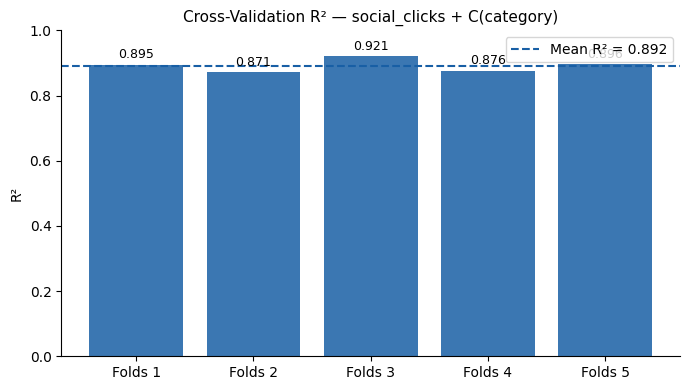

In [12]:
# Visualisasi CV R² model terbaik per fold
fig, ax = plt.subplots(figsize=(7, 4))

folds  = scores_ols_best["folds"].tolist()
scores = scores_ols_best["test_rsquared"].tolist()
mean_r2 = scores_ols_best["test_rsquared"].mean()

bars = ax.bar(folds, scores, color="#185FA5", alpha=0.85, edgecolor="none")
ax.axhline(mean_r2, color="#185FA5", linewidth=1.5, linestyle="--",
           label=f"Mean R² = {mean_r2:.3f}")
ax.set_ylim(0, 1.0)
ax.set_ylabel("R²")
ax.set_title("Cross-Validation R² — social_clicks + C(category)", fontsize=11)
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Conclusion

The graph above shows that the model's performance is **consistent across all folds** —
no single fold has a value significantly below the average, indicating a stable model.

**Summary of key findings:**

1. **Social clicks have a positive effect** on purchases: every 15–16 additional clicks results in one additional purchase.

2. **Product category significantly influences conversions**: Elite consistently generates more purchases than Base at the same click level, while Game falls below Base.

3. **The model is reliable enough** (CV R² = 0.8917) to be used as a basis for campaign planning.

**Strategic recommendations:**

- Focus social advertising budgets on products in the **Elite category** for the highest conversion efficiency.

- To reach the target of 150 purchases, ensure social_clicks reach at least **~2,323** (Base), **~2,161** (Elite), or **~2,414** (Game) per period.
- Reevaluate your content strategy for the **Game** category, as it requires more clicks for the same conversion — there may be an issue with ad or landing page relevance.